## 1. Load dan Preprocessing Data

In [13]:
# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('./dataset/spam.csv', encoding='latin-1')

# Hapus kolom yang tidak diperlukan (Unnamed)
df = df[['v1', 'v2']]

# Ubah nama kolom
df = df.rename(columns={'v1': 'Labels', 'v2': 'SMS'})

print('Ukuran dataset:', df.shape)
df.head()

Ukuran dataset: (5572, 2)


,Labels,SMS
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
# Cek distribusi label
print('=== Distribusi Label ===')
print(df['Labels'].value_counts())
print()

# Cek missing values
print('=== Missing Values ===')
print(df.isnull().sum())

=== Distribusi Label ===
Labels
ham     4825
spam     747
Name: count, dtype: int64

=== Missing Values ===
Labels    0
SMS       0
dtype: int64


In [15]:
	# Data untuk label
new_labels = {
	    'spam': 1,
	    'ham': 0
	}
	
	# Encode label
df['Labels'] = df['Labels'].map(new_labels)
	
	# Cek data
df.head()

,Labels,SMS
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
# Pisahkan fitur (teks) dan label
X = df['SMS']
y = df['Labels']

# Split data training dan testing (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Data Training: {len(X_train)} sampel')
print(f'Data Testing : {len(X_test)} sampel')

Data Training: 4457 sampel
Data Testing : 1115 sampel


---
## 2. Model 1: Multinomial Naive Bayes + CountVectorizer (stop_words)

In [17]:
# Inisiasi CountVectorizer dengan stop_words aktif
bow = CountVectorizer(stop_words='english')

# Transformasi data teks menjadi vektor fitur
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

print(f'Jumlah fitur (vocabulary): {len(bow.get_feature_names_out())}')
print(f'Dimensi data training: {X_train_bow.shape}')
print(f'Dimensi data testing : {X_test_bow.shape}')

Jumlah fitur (vocabulary): 7472
Dimensi data training: (4457, 7472)
Dimensi data testing : (1115, 7472)


In [18]:
# Training model Multinomial Naive Bayes dengan CountVectorizer
mnb_bow = MultinomialNB()
mnb_bow.fit(X_train_bow, y_train)

# Prediksi
y_pred_bow = mnb_bow.predict(X_test_bow)

# Evaluasi
acc_bow = accuracy_score(y_test, y_pred_bow)
print('=' * 55)
print('  HASIL MODEL 1: MNB + CountVectorizer (stop_words)')
print('=' * 55)
print(f'Akurasi: {acc_bow:.4f}')
print(f'\n=== Classification Report ===')
print(classification_report(y_test, y_pred_bow, target_names=['ham', 'spam']))
print(f'=== Confusion Matrix ===')
cm_bow = confusion_matrix(y_test, y_pred_bow)
print(cm_bow)

  HASIL MODEL 1: MNB + CountVectorizer (stop_words)
Akurasi: 0.9839

=== Classification Report ===
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       965
        spam       0.96      0.92      0.94       150

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115

=== Confusion Matrix ===
[[959   6]
 [ 12 138]]


---
## 3. Model 2: Multinomial Naive Bayes + TF-IDF (stop_words)

In [19]:
# Inisiasi TfidfVectorizer dengan stop_words aktif
tfidf = TfidfVectorizer(stop_words='english')

# Transformasi data teks menjadi vektor fitur TF-IDF
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f'Jumlah fitur (vocabulary): {len(tfidf.get_feature_names_out())}')
print(f'Dimensi data training: {X_train_tfidf.shape}')
print(f'Dimensi data testing : {X_test_tfidf.shape}')

Jumlah fitur (vocabulary): 7472
Dimensi data training: (4457, 7472)
Dimensi data testing : (1115, 7472)


In [20]:
# Training model Multinomial Naive Bayes dengan TF-IDF
mnb_tfidf = MultinomialNB()
mnb_tfidf.fit(X_train_tfidf, y_train)

# Prediksi
y_pred_tfidf = mnb_tfidf.predict(X_test_tfidf)

# Evaluasi
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
print('=' * 55)
print('  HASIL MODEL 2: MNB + TF-IDF (stop_words)')
print('=' * 55)
print(f'Akurasi: {acc_tfidf:.4f}')
print(f'\n=== Classification Report ===')
print(classification_report(y_test, y_pred_tfidf, target_names=['ham', 'spam']))
print(f'=== Confusion Matrix ===')
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)
print(cm_tfidf)

  HASIL MODEL 2: MNB + TF-IDF (stop_words)
Akurasi: 0.9668

=== Classification Report ===
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115

=== Confusion Matrix ===
[[965   0]
 [ 37 113]]


---
## 4. Perbandingan Hasil

In [21]:
# Tabel perbandingan
from sklearn.metrics import precision_score, recall_score, f1_score

# Hitung metrik untuk kedua model
metrik = {
    'Metrik': ['Accuracy', 'Precision (spam)', 'Recall (spam)', 'F1-Score (spam)'],
    'CountVectorizer': [
        accuracy_score(y_test, y_pred_bow),
        precision_score(y_test, y_pred_bow),
        recall_score(y_test, y_pred_bow),
        f1_score(y_test, y_pred_bow)
    ],
    'TF-IDF': [
        accuracy_score(y_test, y_pred_tfidf),
        precision_score(y_test, y_pred_tfidf),
        recall_score(y_test, y_pred_tfidf),
        f1_score(y_test, y_pred_tfidf)
    ]
}

df_metrik = pd.DataFrame(metrik)
df_metrik['Selisih'] = df_metrik['CountVectorizer'] - df_metrik['TF-IDF']
df_metrik['Terbaik'] = df_metrik.apply(
    lambda row: 'CountVectorizer' if row['CountVectorizer'] >= row['TF-IDF'] else 'TF-IDF', axis=1
)

print('=' * 75)
print('           PERBANDINGAN COUNTVECTORIZER vs TF-IDF')
print('=' * 75)
print(df_metrik.to_string(index=False))

           PERBANDINGAN COUNTVECTORIZER vs TF-IDF
          Metrik  CountVectorizer   TF-IDF   Selisih         Terbaik
        Accuracy         0.983857 0.966816  0.017040 CountVectorizer
Precision (spam)         0.958333 1.000000 -0.041667          TF-IDF
   Recall (spam)         0.920000 0.753333  0.166667 CountVectorizer
 F1-Score (spam)         0.938776 0.859316  0.079460 CountVectorizer


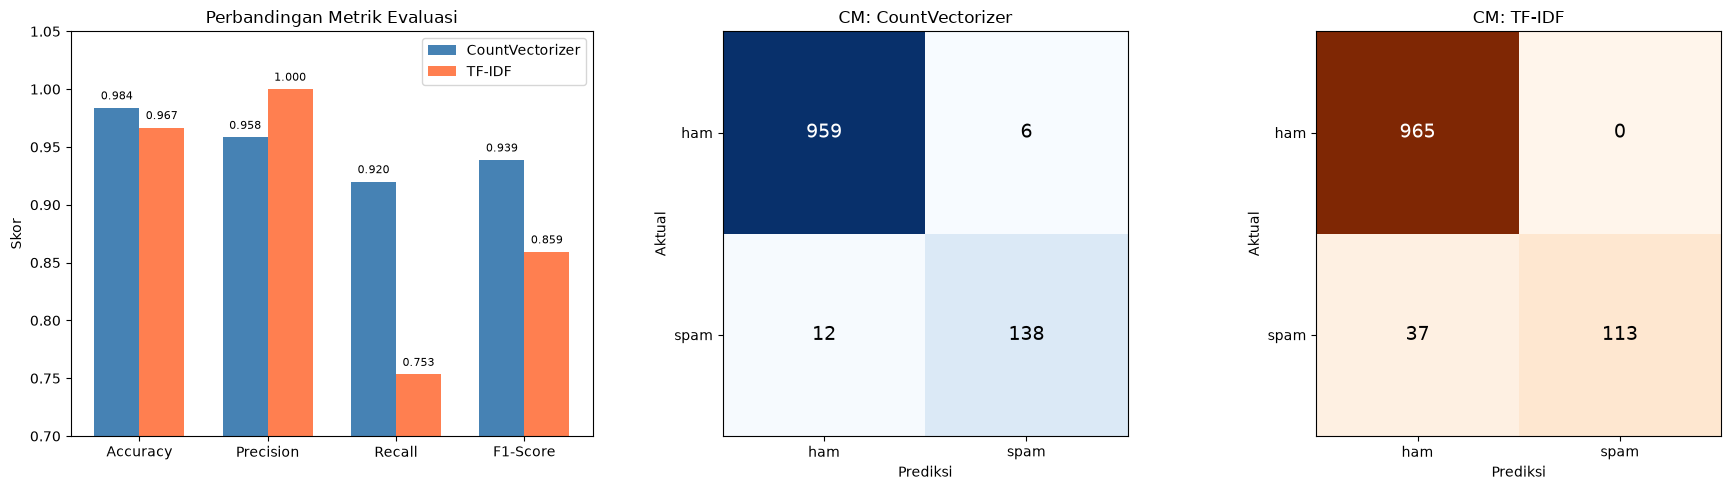

In [22]:
# Visualisasi perbandingan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Grafik 1: Perbandingan Metrik ---
metrik_nama = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
bow_scores = [acc_bow, 
              precision_score(y_test, y_pred_bow),
              recall_score(y_test, y_pred_bow),
              f1_score(y_test, y_pred_bow)]
tfidf_scores = [acc_tfidf,
                precision_score(y_test, y_pred_tfidf),
                recall_score(y_test, y_pred_tfidf),
                f1_score(y_test, y_pred_tfidf)]

x_pos = np.arange(len(metrik_nama))
width = 0.35

bars1 = axes[0].bar(x_pos - width/2, bow_scores, width, label='CountVectorizer', color='steelblue')
bars2 = axes[0].bar(x_pos + width/2, tfidf_scores, width, label='TF-IDF', color='coral')

axes[0].set_ylabel('Skor')
axes[0].set_title('Perbandingan Metrik Evaluasi')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(metrik_nama)
axes[0].legend()
axes[0].set_ylim(0.7, 1.05)

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# --- Grafik 2: Confusion Matrix - CountVectorizer ---
im1 = axes[1].imshow(cm_bow, cmap='Blues')
axes[1].set_title('CM: CountVectorizer')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['ham', 'spam'])
axes[1].set_yticklabels(['ham', 'spam'])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm_bow[i, j]), ha='center', va='center',
                     color='white' if cm_bow[i, j] > cm_bow.max()/2 else 'black', fontsize=14)

# --- Grafik 3: Confusion Matrix - TF-IDF ---
im2 = axes[2].imshow(cm_tfidf, cmap='Oranges')
axes[2].set_title('CM: TF-IDF')
axes[2].set_xlabel('Prediksi')
axes[2].set_ylabel('Aktual')
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(['ham', 'spam'])
axes[2].set_yticklabels(['ham', 'spam'])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm_tfidf[i, j]), ha='center', va='center',
                     color='white' if cm_tfidf[i, j] > cm_tfidf.max()/2 else 'black', fontsize=14)

plt.tight_layout()
plt.show()

---
## 5. Kesimpulan

In [23]:
# Kesimpulan otomatis berdasarkan hasil
print('=' * 60)
print('                      KESIMPULAN')
print('=' * 60)

if acc_bow > acc_tfidf:
    winner = 'CountVectorizer'
    selisih = acc_bow - acc_tfidf
elif acc_tfidf > acc_bow:
    winner = 'TF-IDF'
    selisih = acc_tfidf - acc_bow
else:
    winner = 'Keduanya sama'
    selisih = 0

print(f'\n1. Akurasi CountVectorizer : {acc_bow:.4f}')
print(f'   Akurasi TF-IDF          : {acc_tfidf:.4f}')
print(f'   Selisih                 : {selisih:.4f}')

recall_bow = recall_score(y_test, y_pred_bow)
recall_tfidf = recall_score(y_test, y_pred_tfidf)
print(f'\n2. Recall (spam) CountVectorizer : {recall_bow:.4f}')
print(f'   Recall (spam) TF-IDF          : {recall_tfidf:.4f}')

print(f'\n3. Fitur terbaik pada kasus spam.csv: **{winner}**')
print(f'\n   Alasan:')
if winner == 'CountVectorizer':
    print('   - CountVectorizer memberikan akurasi yang lebih tinggi.')
    print('   - Pada kasus deteksi spam, CountVectorizer (Bag of Words)')
    print('     bekerja lebih baik karena frekuensi kemunculan kata-kata')
    print('     tertentu (seperti "free", "win", "prize") sudah cukup')
    print('     menjadi indikator kuat untuk mengidentifikasi spam.')
    print('   - TF-IDF cenderung menurunkan bobot kata-kata yang sering')
    print('     muncul di banyak dokumen, padahal kata-kata spam justru')
    print('     sering muncul dan merupakan fitur penting.')
elif winner == 'TF-IDF':
    print('   - TF-IDF memberikan akurasi yang lebih tinggi.')
    print('   - TF-IDF mempertimbangkan bobot kata berdasarkan')
    print('     frekuensi relatifnya di seluruh dokumen, sehingga')
    print('     kata-kata unik yang membedakan spam dan ham mendapat')
    print('     bobot yang lebih tinggi.')
    print('   - Normalisasi yang dilakukan TF-IDF membantu model')
    print('     menangani variasi panjang teks SMS yang berbeda-beda.')
else:
    print('   - Kedua fitur memberikan performa yang sama.')
    print('   - Perlu analisis lebih lanjut dengan metrik lain.')

                      KESIMPULAN

1. Akurasi CountVectorizer : 0.9839
   Akurasi TF-IDF          : 0.9668
   Selisih                 : 0.0170

2. Recall (spam) CountVectorizer : 0.9200
   Recall (spam) TF-IDF          : 0.7533

3. Fitur terbaik pada kasus spam.csv: **CountVectorizer**

   Alasan:
   - CountVectorizer memberikan akurasi yang lebih tinggi.
   - Pada kasus deteksi spam, CountVectorizer (Bag of Words)
     bekerja lebih baik karena frekuensi kemunculan kata-kata
     tertentu (seperti "free", "win", "prize") sudah cukup
     menjadi indikator kuat untuk mengidentifikasi spam.
   - TF-IDF cenderung menurunkan bobot kata-kata yang sering
     muncul di banyak dokumen, padahal kata-kata spam justru
     sering muncul dan merupakan fitur penting.
